# **Advanced Multi-Model Comparison Notebook**
### *ResNet18 vs EfficientNet-B0 vs MobileNetV3*
This notebook loads prediction files from three separate model directories, computes ROC/PR metrics, generates publication-quality comparison plots, and performs **DeLong tests** to statistically compare ROC curves.

In [4]:
# === USER: Set Model Directories ===
from google.colab import drive
drive.mount('/content/drive')

RESNET18_DIR = "/content/drive/MyDrive/AIMLGroup18/Ekyaalo_Binary_Classifier/ResNet18/"
EFFNETB0_DIR = "/content/drive/MyDrive/AIMLGroup18/Ekyaalo_Binary_Classifier/EfficientNet_B0/"
MOBILENETV3_DIR = "/content/drive/MyDrive/AIMLGroup18/Ekyaalo_Binary_Classifier/MobileNet_V3/"
DINO_DIR = "/content/drive/MyDrive/AIMLGroup18/Ekyaalo_ViT/TilePreds/"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix


In [5]:
def load_model_tiles(model_dir):
    frames = []
    for i in range(5):
        fpath = os.path.join(model_dir, f"tile_preds_fold_{i}.csv")
        if os.path.exists(fpath):
            df = pd.read_csv(fpath)
            df["fold"] = i
            frames.append(df)
        else:
            print("Missing file:", fpath)
    return pd.concat(frames).reset_index(drop=True)

tiles_resnet = load_model_tiles(RESNET18_DIR)
tiles_effb0 = load_model_tiles(EFFNETB0_DIR)
tiles_mnetv3 = load_model_tiles(MOBILENETV3_DIR)
tiles_dino = load_model_tiles(DINO_DIR)

print("Loaded prediction files for all models.")


Loaded prediction files for all models.


In [6]:
def compute_metrics(df):
    y_true = df["y_true"].values
    y_prob = df["y_prob"].values
    y_pred = df["y_pred"].values

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    pr, rc, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(rc, pr)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    return {
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "confusion_matrix": cm
    }

metrics = {
    "ResNet18": compute_metrics(tiles_resnet),
    "EffNetB0": compute_metrics(tiles_effb0),
    "MobileNetV3": compute_metrics(tiles_mnetv3),
    "DINO": compute_metrics(tiles_dino)
}

pd.DataFrame(metrics).T


,roc_auc,pr_auc,sensitivity,specificity,confusion_matrix
ResNet18,0.974476,0.986696,0.995465,0.878049,"[[144, 20], [2, 439]]"
EffNetB0,0.965108,0.983402,0.959184,0.853659,"[[140, 24], [18, 423]]"
MobileNetV3,0.969319,0.985948,0.981859,0.878049,"[[144, 20], [8, 433]]"
DINO,0.938471,0.96226,0.977324,0.817073,"[[134, 30], [10, 431]]"


## **ROC Curve Comparison (Publication Ready)**

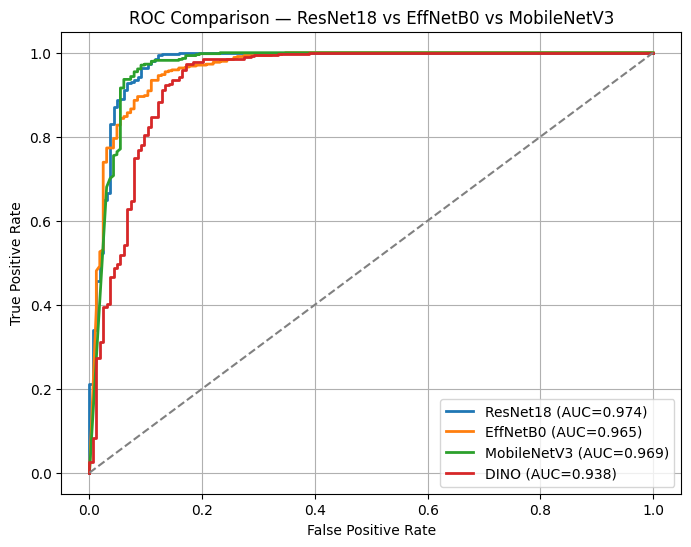

In [7]:
plt.figure(figsize=(8,6))

for name, df in zip(
    ["ResNet18", "EffNetB0", "MobileNetV3", "DINO"],
    [tiles_resnet, tiles_effb0, tiles_mnetv3, tiles_dino]
):
    fpr, tpr, _ = roc_curve(df["y_true"], df["y_prob"])
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison — ResNet18 vs EffNetB0 vs MobileNetV3")
plt.legend()
plt.grid(True)
plt.show()


## **Precision-Recall Curve Comparison**

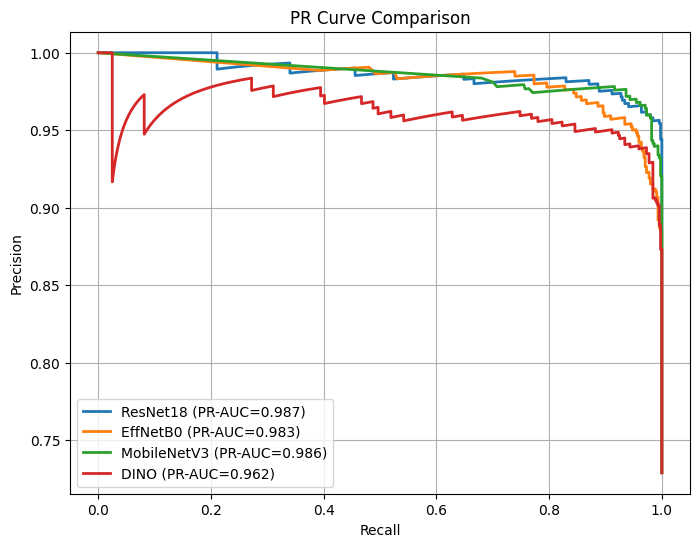

In [8]:
plt.figure(figsize=(8,6))

for name, df in zip(
    ["ResNet18", "EffNetB0", "MobileNetV3", "DINO"],
    [tiles_resnet, tiles_effb0, tiles_mnetv3, tiles_dino]
):
    pr, rc, _ = precision_recall_curve(df["y_true"], df["y_prob"])
    pr_auc = auc(rc, pr)
    plt.plot(rc, pr, lw=2, label=f"{name} (PR-AUC={pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()
